Imports

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import copy
from torchsummary import summary

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Using CPU')

Using CPU


Dataset Paths for OUR MASTER dataset

In [9]:
train_dir = r"D:\Master_dataset\train"
val_dir = r"D:\Master_dataset\val"
test_dir = r"D:\Master_dataset\test"

Transforms

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


DataLoaders

In [ ]:
# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Train class_to_idx:", train_dataset.class_to_idx)
print("Val class_to_idx:", val_dataset.class_to_idx)
print("Test class_to_idx:", test_dataset.class_to_idx)

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 14054
Val size: 1757
Test size: 1757
Counter({0: 879, 1: 878})
Train class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
Val class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}
Test class_to_idx: {'NORMAL': 0, 'PNEUMONIA': 1}


ALEXNET MODEL

In [12]:
def build_alexnet():
    model = models.alexnet(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(9216, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Linear(1024, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, 32),
        nn.ReLU(inplace=True),
        nn.Linear(32, 2)
    )
    return model

RESNET18 MODEL

In [13]:
def build_resnet18():
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(),
        nn.Linear(512, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, 32),
        nn.ReLU(inplace=True),
        nn.Linear(32, 2),
        nn.ReLU(inplace=True)
    )
    return model

Load Models

In [14]:
def load_model(model_name, path, device):
    if model_name == "alexnet":
        model = build_alexnet()
    elif model_name == "resnet18":
        model = build_resnet18()
    else:
        raise ValueError("Unknown model name")

    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

In [15]:
criterion = nn.CrossEntropyLoss()

alexnet_model = load_model("alexnet", "alexnet_finetuned_baseline.pth", device)
resnet_model = load_model("resnet18", "resnet18_finetuned_baseline.pth", device)

FGSM attack

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

x_min = (0.0 - mean) / std
x_max = (1.0 - mean) / std
# --- FGSM ---
def fgsm_attack(x, epsilon, grad, x_min, x_max):
    x_adv = x + epsilon * grad.sign()
    x_adv = torch.max(torch.min(x_adv, x_max), x_min)
    return x_adv

# --- Evaluation loop ---
def evaluate_fgsm(model, loader, epsilon):
    loss_fn = nn.CrossEntropyLoss()
    correct_clean = 0
    correct_adv   = 0
    total         = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad = True

        # Clean accuracy
        out = model(images)
        correct_clean += (out.argmax(1) == labels).sum().item()

        # Compute gradient w.r.t. input
        loss = loss_fn(out, labels) # FIX: Use out.logits here
        model.zero_grad()
        loss.backward()

        # Perturb and re-evaluate
        adv_images = fgsm_attack(images, epsilon, images.grad.data, x_min, x_max)
        with torch.no_grad():
            adv_out = model(adv_images)
        correct_adv += (adv_out.argmax(1) == labels).sum().item()

        total += labels.size(0)

    clean_acc = 100 * correct_clean / total
    adv_acc   = 100 * correct_adv   / total
    print(f"ε={epsilon:.3f} | Clean acc: {clean_acc:.1f}%  Adv acc: {adv_acc:.1f}%  "
          f"Drop: {clean_acc - adv_acc:.1f}%")
    return clean_acc, adv_acc

Run FGSM from eps 0.01 to 0.1 for AlexNet

In [ ]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
alexnet_results = [evaluate_fgsm(alexnet_model, test_loader, eps)[1] for eps in epsilons]

c:\Users\DVU20\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ε=0.000 | Clean acc: 77.9%  Adv acc: 77.9%  Drop: 0.0%
ε=0.010 | Clean acc: 77.9%  Adv acc: 10.4%  Drop: 67.5%
ε=0.030 | Clean acc: 77.9%  Adv acc: 1.1%  Drop: 76.8%
ε=0.050 | Clean acc: 77.9%  Adv acc: 0.6%  Drop: 77.3%
ε=0.100 | Clean acc: 77.9%  Adv acc: 1.7%  Drop: 76.3%


Run FGSM from eps 0.01 to 0.1 for ResNet-18

In [ ]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
resnet_results = [evaluate_fgsm(resnet_model, test_loader, eps)[1] for eps in epsilons]


c:\Users\DVU20\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


ε=0.000 | Clean acc: 75.3%  Adv acc: 75.3%  Drop: 0.0%
ε=0.010 | Clean acc: 75.3%  Adv acc: 23.3%  Drop: 52.0%
ε=0.030 | Clean acc: 75.3%  Adv acc: 40.4%  Drop: 34.9%
ε=0.050 | Clean acc: 75.3%  Adv acc: 43.9%  Drop: 31.4%
ε=0.100 | Clean acc: 75.3%  Adv acc: 50.7%  Drop: 24.6%


In [29]:

print(resnet_results)

[75.2988047808765, 75.2988047808765, 75.2988047808765, 75.2988047808765, 75.2988047808765]


Accuracy vs eps curves for alexnet and resnet

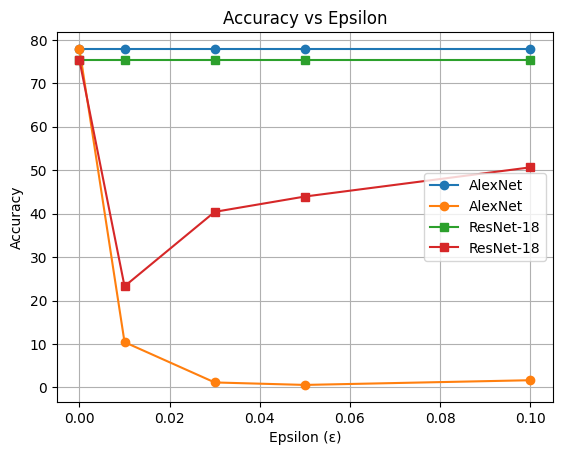

In [21]:
import matplotlib.pyplot as plt

# Plot both curves
plt.plot(epsilons, alexnet_results, marker='o', label='AlexNet')
plt.plot(epsilons, resnet_results, marker='s', label='ResNet-18')

# Labels and title
plt.xlabel('Epsilon (ε)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon')

# Legend
plt.legend()

# Show
plt.grid(True)
plt.show()